# Logistic equation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

## Logistic growth model

$$
    \frac{\text{d}y}{\text{d}t} = r y (1 - y / K ),
$$

where $r$ and $K$ are parameters.

## Function calculating the value of the right side of the model equation

In [2]:
def logistic_model(t, state, r=1, K=1):
    return r*state*( 1 - state/K )

## Set values of $r$ and $K$

In [3]:
r = 0.1
K = 2000

## Set time values at which we want to evaluate the model

In [4]:
t_span = [0, 200]
state_initial = 100

In [5]:
solution = solve_ivp(logistic_model, t_span, [state_initial], args=(r, K), max_step=t_span[1]/100)

Text(0.5, 1.0, '$r$ = 0.1; $K$ = 2000, $N(0)$ = 100')

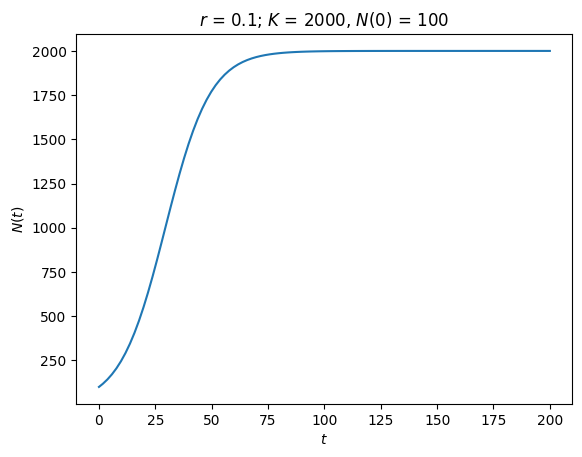

In [6]:
_, ax = plt.subplots()

ax.plot(solution.t, solution.y[0])
ax.set_ylabel('$N(t)$')
ax.set_xlabel('$t$')
ax.set_title(f"$r$ = {r}; $K$ = {K}, $N(0)$ = {state_initial}")

# Repdoruce figures from the lecture notes

## Figure 1.1

##### Generate solutions with various parameter values

In [7]:
# rs = [0.01, 0.02, 0.03]
# state_inits = [100, 350, 600]

rs = np.arange(0.01, 0.1, 0.02)
state_inits = np.arange(50, 2500, 400)

t_span_fig1_1 = [0, 1000]

solutions_vary_r = []
solutions_vary_init = []

for r_ in rs:
    ss = solve_ivp(logistic_model, t_span_fig1_1, [state_initial], args=(r_, K), max_step=t_span[1]/100)
    ss.r = r_
    solutions_vary_r.append(ss)

for state_init_ in state_inits:
    ss = solve_ivp(logistic_model, t_span_fig1_1, [state_init_], args=(rs[0], K), max_step=t_span[1]/100)
    ss.state_initial = state_init_
    solutions_vary_init.append(ss)

##### Make figure

Text(0.5, 1.0, '$r$ = 0.01; $K$ = 2000')

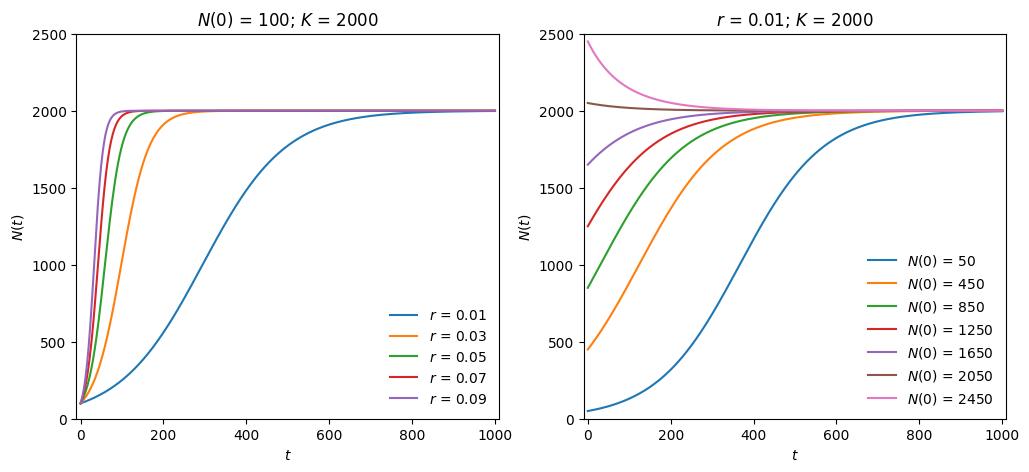

In [8]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))

for ss in solutions_vary_r:
    ax1.plot(ss.t, ss.y[0], label=f"$r$ = {np.round(ss.r, 2)}")

for ss in solutions_vary_init:
    ax2.plot(ss.t, ss.y[0], label=f"$N(0)$ = {ss.state_initial}")

for ax in (ax1, ax2):
    ax.legend(frameon=False)
    ax.set_ylabel('$N(t)$')
    ax.set_xlabel('$t$')
    ax.set_ylim(0, 2500)
    ax.set_xlim(-10, 1010)

ax1.set_title(f'$N(0)$ = {state_initial}; $K$ = {K}')
ax2.set_title(f'$r$ = {rs[0]}; $K$ = {K}')

## Figure 1.2. Vector field and a trajectory

In [9]:
n_points = 20
T, Y = np.meshgrid(np.linspace(t_span[0], t_span[1], n_points),
                   np.linspace(-50, 2500, n_points))

dy = logistic_model(0, Y, r=r, K=K)

time_step = np.diff(T[0])[0]
dt = np.ones(dy.shape)*time_step

norm = np.linalg.norm([dt, dy], axis=0)

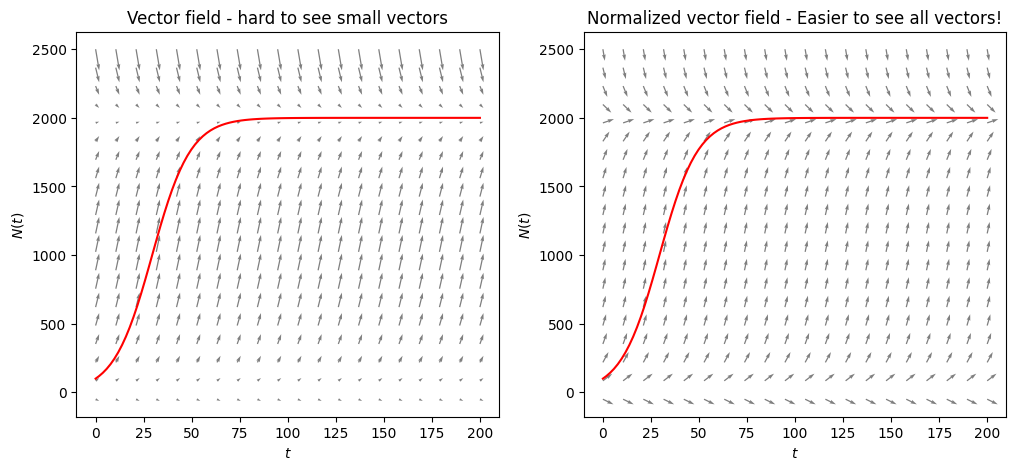

In [10]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

ax1.quiver(T, Y, dt, dy, color='k', alpha=0.5)
ax1.plot(solution.t, solution.y[0], color='r')

ax2.quiver(T, Y, dt/norm, dy/norm, color='k', alpha=0.5)
ax2.plot(solution.t, solution.y[0], color='r')

ax1.set_title('Vector field - hard to see small vectors')
ax2.set_title('Normalized vector field - Easier to see all vectors!')

for ax in (ax1, ax2):
    ax.set_ylabel("$N(t)$")
    ax.set_xlabel('$t$')